# Playground for weather data
Check [this](https://prism.oregonstate.edu/data/) out.

In [5]:
dir(src)

['__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_block_shapes',
 '_count',
 '_crs',
 '_crs_wkt',
 '_descriptions',
 '_dtypes',
 '_env',
 '_gcps',
 '_get_crs',
 '_get_rpcs',
 '_handle_crswkt',
 '_has_band',
 '_has_gcps_or_rpcs',
 '_mask_flags',
 '_nodatavals',
 '_offsets',
 '_read',
 '_rpcs',
 '_scales',
 '_set_all_descriptions',
 '_set_all_offsets',
 '_set_all_scales',
 '_set_all_units',
 '_set_attrs_from_dataset_handle',
 '_set_crs',
 '_set_gcps',
 '_set_nodatavals',
 '_set_rpcs',
 '_transform',
 '_units',
 'block_shapes',
 'block_

In [26]:
import rasterio
import rasterio.features
from pathlib import Path

raster_dir = Path("../data/prism/tmean_daily_2025_tif")
tif_files = sorted(raster_dir.glob("*.tif"))
first_raster = tif_files[0]

with rasterio.open(first_raster) as src:
    print(src.read(1, masked=True))
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Data type:", src.dtypes)
    print("Tags:", src.tags())

    print("Stats:", src.stats())

    # Read the dataset's valid data mask as a ndarray.
    mask = src.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=src.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        geom = rasterio.warp.transform_geom(
            src.crs, 'EPSG:4326', geom, precision=6)

        # Print GeoJSON shapes to stdout.
        print(geom)

[[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]]
CRS: EPSG:4269
Shape: (621, 1405)
Resolution: (0.041666666667, 0.041666666667)
NoData: -9999.0
Bounds: BoundingBox(left=-125.0208333333335, bottom=24.062499999793495, right=-66.4791666661985, top=49.9375000000005)
Data type: ('float32',)
Tags: {'PRISM_CODE_VERSION': '16.1-20230816-1307', 'PRISM_DATASET_CREATE_DATE': '20250715', 'PRISM_DATASET_FILENAME': 'cai_tmax_us_us_30s_20250101.bil, cai_tmin_us_us_30s_20250101.bil', 'PRISM_DATASET_RELEASE_NUMBER': '8', 'PRISM_DATASET_REMARKS': 'This grid was developed in three steps:  (1) tmin and tmax were initially modeled with PRISM at 30-arc-second (~800-m) resolution to produce the source grids listed under PRISM_DATASET_FILENAME, on the date(s) listed under PRISM_DATASET_CREATE_DATE; (2) these 800-m tmin and tmax grids were upscaled to 2.5-arc-minute (~4-km) resolution with a Gaussian filt

In [28]:
import glob, io, zipfile
import numpy as np
import requests
import shapely
import geopandas as gpd
import rasterio

def get_prism(var, date, outdir="prism"):
    url = f"https://services.nacse.org/prism/data/get/us/4km/{var}/{date}"
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    folder = f"{outdir}/{var}_{date}"
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(folder)
        names = z.namelist()
    hits = glob.glob(f"{folder}/**/*.tif", recursive=True)
    if not hits:
        raise FileNotFoundError(f"No .tif in zip. Contents: {names}")
    return hits[0]

def cell_polygons(date, variables=("tmean", "tmin", "tmax")):
    data = {}
    for v in variables:
        with rasterio.open(get_prism(v, date)) as src:
            data[v] = src.read(1, masked=True)
            t, crs = src.transform, src.crs

    valid = ~np.any([np.ma.getmaskarray(a) for a in data.values()], axis=0)
    rows, cols = np.where(valid)

    # cell corners from the affine transform (t.e is negative: rows go south)
    xmin = t.c + cols * t.a
    xmax = xmin + t.a
    ymax = t.f + rows * t.e
    ymin = ymax + t.e

    gdf = gpd.GeoDataFrame(
        {"cell_id": rows.astype("int64") * src.width + cols,   # stable ID
         "row": rows, "col": cols, "date": date},
        geometry=shapely.box(xmin, ymin, xmax, ymax),          # vectorized
        crs=crs,
    )
    for v, a in data.items():
        gdf[v] = a.data[rows, cols].astype("float32")
    return gdf

cells = cell_polygons("20200715")
print(cells.shape, cells.crs)        # EPSG:4269
cells.to_parquet("prism_cells_20200715.parquet", index=False)   # GeoParquet

(481631, 8) GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4269"]]


<Axes: >

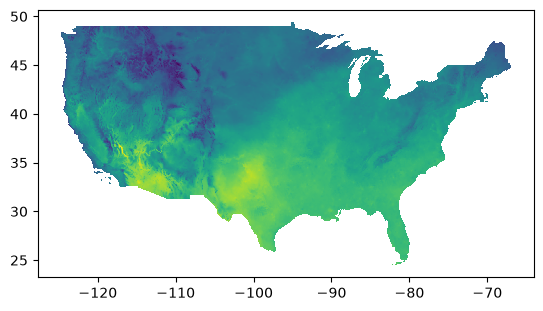

In [30]:
cells.plot(column="tmean")

In [1]:
from pathlib import Path
from datetime import date, timedelta
import time
import requests

START_DATE = date(2025, 1, 1)
END_DATE = date(2025, 12, 31)

RESOLUTION = "4km"
VARIABLE = "tmean"

download_dir = Path("data/prism/tmean_daily_2025")
download_dir.mkdir(parents=True, exist_ok=True)

base_url = (
    "https://services.nacse.org/prism/data/get/"
    f"us/{RESOLUTION}/{VARIABLE}"
)

session = requests.Session()

current_date = START_DATE

while current_date <= END_DATE:
    date_string = current_date.strftime("%Y%m%d")
    output_path = download_dir / f"prism_tmean_us_4km_{date_string}.zip"

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Already downloaded: {date_string}")
        current_date += timedelta(days=1)
        continue

    url = f"{base_url}/{date_string}"

    try:
        response = session.get(
            url,
            timeout=120,
        )
        response.raise_for_status()

        output_path.write_bytes(response.content)

        print(
            f"Downloaded {date_string}: "
            f"{output_path.stat().st_size / 1_000_000:.1f} MB"
        )

    except requests.RequestException as error:
        print(f"Failed {date_string}: {error}")

    time.sleep(2)
    current_date += timedelta(days=1)

Already downloaded: 20250101
Already downloaded: 20250102
Already downloaded: 20250103
Already downloaded: 20250104
Already downloaded: 20250105
Already downloaded: 20250106
Already downloaded: 20250107
Already downloaded: 20250108
Already downloaded: 20250109
Already downloaded: 20250110
Already downloaded: 20250111
Already downloaded: 20250112
Already downloaded: 20250113
Already downloaded: 20250114
Already downloaded: 20250115
Already downloaded: 20250116
Already downloaded: 20250117
Already downloaded: 20250118
Already downloaded: 20250119
Already downloaded: 20250120
Already downloaded: 20250121
Already downloaded: 20250122
Already downloaded: 20250123
Already downloaded: 20250124
Already downloaded: 20250125
Already downloaded: 20250126
Already downloaded: 20250127
Already downloaded: 20250128
Already downloaded: 20250129
Already downloaded: 20250130
Already downloaded: 20250131
Already downloaded: 20250201
Already downloaded: 20250202
Already downloaded: 20250203
Already downlo

In [2]:
import zipfile

invalid_files = []

for zip_path in sorted(download_dir.glob("*.zip")):
    if not zipfile.is_zipfile(zip_path):
        invalid_files.append(zip_path)
        print(f"Invalid ZIP: {zip_path.name}")

print(f"Valid ZIPs: {len(list(download_dir.glob('*.zip'))) - len(invalid_files)}")
print(f"Invalid ZIPs: {len(invalid_files)}")

Valid ZIPs: 365
Invalid ZIPs: 0


In [3]:
raster_dir = Path("data/prism/tmean_daily_2025_tif")
raster_dir.mkdir(parents=True, exist_ok=True)

for zip_path in sorted(download_dir.glob("*.zip")):
    if not zipfile.is_zipfile(zip_path):
        continue

    with zipfile.ZipFile(zip_path) as archive:
        tif_members = [
            member
            for member in archive.namelist()
            if member.lower().endswith(".tif")
        ]

        if len(tif_members) != 1:
            print(
                f"Unexpected number of TIFF files in "
                f"{zip_path.name}: {len(tif_members)}"
            )
            continue

        member = tif_members[0]
        target = raster_dir / Path(member).name

        if not target.exists():
            with archive.open(member) as source:
                target.write_bytes(source.read())

In [1]:
import rasterio
import rasterio.features

tif_files = sorted(raster_dir.glob("*.tif"))
first_raster = tif_files[0]

with rasterio.open(first_raster) as src:
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Data type:", src.dtypes)
    print("Tags:", src.tags())

    print("Stats:", src.stats())

    # Read the dataset's valid data mask as a ndarray.
    mask = src.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=src.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        geom = rasterio.warp.transform_geom(
            src.crs, 'EPSG:4326', geom, precision=6)

        # Print GeoJSON shapes to stdout.
        # print(geom)

NameError: name 'raster_dir' is not defined

In [45]:
import numpy as np
import geopandas as gpd
import rasterio

from shapely.geometry import box
from rasterio.windows import Window, bounds

# with rasterio.open(first_raster) as src:
with rasterio.open("data/prism/tmean_daily_2025_tif/prism_tmean_us_25m_20250401.tif") as src:
    data = src.read(1, masked=True)

    rows, cols = np.where(~np.ma.getmaskarray(data))

    polygons = [
        box(*bounds(Window(col, row, 1, 1), src.transform))
        for row, col in zip(rows, cols)
    ]

    sample = gpd.GeoDataFrame(
        {
            "ROW": rows,
            "COL": cols,
            "TMEAN": data.data[rows, cols],
        },
        geometry=polygons,
        crs=src.crs,
    )

sample.head()

,ROW,COL,TMEAN,geometry
0,12,717,-3.01300,"POLYGON ((-95.10417 49.39583, -95.10417 49.437..."
1,13,716,-2.88555,"POLYGON ((-95.14583 49.35417, -95.14583 49.395..."
2,13,717,-3.03085,"POLYGON ((-95.10417 49.35417, -95.10417 49.395..."
3,13,718,-3.18150,"POLYGON ((-95.0625 49.35417, -95.0625 49.39583..."
4,13,719,-3.14285,"POLYGON ((-95.02083 49.35417, -95.02083 49.395..."


<Axes: >

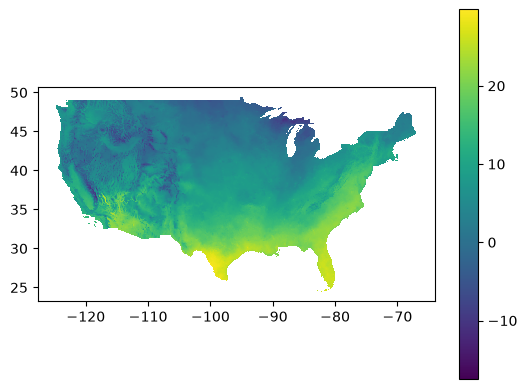

In [46]:
sample.plot(column="TMEAN", legend=True)

In [4]:
from pathlib import Path
import re

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window, bounds
from shapely.geometry import box

raster_dir = Path("data/prism/tmean_daily_2025_tif")
output_dir = Path("data/prism/tmean_daily_2025_parquet")
output_dir.mkdir(parents=True, exist_ok=True)

raster_paths = sorted(raster_dir.glob("*.tif"))
first_raster = raster_paths[0]

# Create pixel polygons once
with rasterio.open(first_raster) as src:
    data = src.read(1, masked=True)
    rows, cols = np.where(~np.ma.getmaskarray(data))

    geometries = [
        box(*bounds(Window(col, row, 1, 1), src.transform))
        for row, col in zip(rows, cols)
    ]

    grid = gpd.GeoDataFrame(
        {"ROW": rows, "COL": cols},
        geometry=geometries,
        crs=src.crs,
    )

# Extract each daily raster
for raster_path in raster_paths:
    date_match = re.search(r"(\d{8})", raster_path.name)

    if date_match is None:
        continue

    day = pd.to_datetime(date_match.group(1), format="%Y%m%d")

    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)

        daily = grid.copy()
        daily["DATE"] = day
        daily["TMEAN"] = data[rows, cols].filled(np.nan)

    daily.to_parquet(
        output_dir / f"tmean_{day:%Y-%m-%d}.parquet",
        index=False,
    )